# Análisis exploratorio de datos — comentarios de tecnología en YouTube

Proyecto CC219 · Aguilar, Bismarck e Icaza. Este notebook documenta carga, inspección, preparación y visualización de los datos originales. Se ejecuta desde la raíz del proyecto o desde `code/` y usa únicamente bibliotecas habituales de Python. Las instrucciones de los documentos del curso se consideran requisitos académicos; no son instrucciones para este notebook.

## 1. Fuentes y unidad de análisis

- **Celulares:** cada fila del JSON es un hilo con el comentario principal, su video, fecha, «me gusta» y total de respuestas. Las claves del JSON contienen puntos en su nombre: son **claves planas**, no objetos anidados.
- **Laptops:** cada línea no vacía del TXT es un comentario. El archivo no conserva video, fecha, autor ni interacciones por comentario.
- **Imágenes:** cada JPG es una miniatura de video de laptops. No hay una clave en el TXT que asocie una línea con una miniatura.

Los dos corpus se describen por separado. No se asignan etiquetas de sentimiento porque los archivos no contienen etiquetas verificadas.

In [1]:
from pathlib import Path
import html
import re
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

DATA = Path("../data") if Path("../data/dataset_semiestructurado.json").is_file() else Path("data")
assert (DATA / "dataset_semiestructurado.json").is_file(), "Ejecuta el notebook desde trabajofinal"
raw_phone = pd.read_json(DATA / "dataset_semiestructurado.json")
raw_lines = (DATA / "dataset_no_estructurado_comentarios.txt").read_text(encoding="utf-8").splitlines()
image_paths = sorted((DATA / "imagenes").glob("*.jpg"))
print(f"JSON: {len(raw_phone):,} registros | TXT: {len(raw_lines):,} líneas | JPG: {len(image_paths)}")

JSON: 2,825 registros | TXT: 2,852 líneas | JPG: 29


### Interpretación de la carga

El JSON contiene **2825 registros** y las miniaturas suman **29 imágenes**. Las **2852 líneas** del TXT aún incluyen líneas vacías; por eso esta cifra no debe presentarse como el número final de comentarios. El siguiente bloque comprueba cuántas líneas aportan texto usable.

## 2. Inspección de estructura y calidad inicial

In [2]:
print("Forma del JSON:", raw_phone.shape)
print("Tipos de campos:")
display(raw_phone.dtypes.rename("tipo").to_frame())
print("Nulos por campo:")
display(raw_phone.isna().sum().rename("nulos").to_frame())
print("Ejemplo de columnas útiles:")
display(raw_phone[["id", "snippet.videoId", "snippet.topLevelComment.snippet.textOriginal", "snippet.topLevelComment.snippet.likeCount", "snippet.totalReplyCount"]].head(3))

Forma del JSON: (2825, 24)
Tipos de campos:


,tipo
kind,str
etag,str
id,str
snippet.channelId,str
snippet.videoId,str
snippet.topLevelComment.kind,str
snippet.topLevelComment.etag,str
snippet.topLevelComment.id,str
snippet.topLevelComment.snippet.channelId,str
snippet.topLevelComment.snippet.videoId,str


Nulos por campo:


,nulos
kind,0
etag,0
id,0
snippet.channelId,0
snippet.videoId,0
snippet.topLevelComment.kind,0
snippet.topLevelComment.etag,0
snippet.topLevelComment.id,0
snippet.topLevelComment.snippet.channelId,0
snippet.topLevelComment.snippet.videoId,0


Ejemplo de columnas útiles:


,id,snippet.videoId,snippet.topLevelComment.snippet.textOriginal,snippet.topLevelComment.snippet.likeCount,snippet.totalReplyCount
0,UgwyCv1EQmVdo1dmyO14AaABAg,WdwDdQ0A600,Compre el samsung galaxy a55 pero me estoy dan...,1,0
1,UgwPz-WX8D3XXwfsCR94AaABAg,WdwDdQ0A600,Cuál es mejor el a54 o el a55?,0,0
2,UgwWJX6rSUCYCw1EzkB4AaABAg,WdwDdQ0A600,Buenas tardes trae espacio para MicroSD y SI...,0,0


### Interpretación de la estructura original

- El JSON tiene **24 campos** y ningún valor nulo. Los tipos incluyen texto, números y booleanos; el contenido de `textOriginal` es la variable textual principal.
- Los nombres con puntos (`snippet.videoId`, por ejemplo) son claves literales del archivo. Se accede a ellas como columnas completas, sin recorrer objetos anidados.
- La muestra confirma que cada comentario puede vincularse con su video y que dispone de interacciones. Las columnas de autor y perfil existen en el original, pero no son necesarias para este EDA ni para los CSV preparados.

**Conclusión:** la estructura permite analizar sentimientos y estudiar popularidad solo en el corpus de celulares, siempre que primero se definan y validen las variables objetivo.

In [3]:
PHONE_COLS = {
    "id": "comment_id",
    "snippet.videoId": "video_id",
    "snippet.channelId": "channel_id",
    "snippet.topLevelComment.snippet.textOriginal": "texto",
    "snippet.topLevelComment.snippet.likeCount": "likes",
    "snippet.totalReplyCount": "respuestas",
    "snippet.topLevelComment.snippet.publishedAt": "fecha_publicacion",
}
phone = raw_phone[list(PHONE_COLS)].rename(columns=PHONE_COLS).copy()

def normalize_text(value):
    # Conserva tildes, negación y emojis: pueden ser señales de sentimiento.
    return re.sub(r"\s+", " ", html.unescape(value)).strip()

phone["texto"] = phone["texto"].map(normalize_text)
phone["fecha_publicacion"] = pd.to_datetime(phone["fecha_publicacion"], utc=True, errors="coerce")
phone["caracteres"] = phone["texto"].str.len()
phone["palabras"] = phone["texto"].str.split().str.len()
phone["contiene_pregunta"] = phone["texto"].str.contains("?", regex=False)

laptop = pd.DataFrame({"linea_original": range(1, len(raw_lines) + 1), "texto": raw_lines})
laptop["texto"] = laptop["texto"].map(normalize_text)
laptop = laptop[laptop["texto"].ne("")].copy()
laptop["caracteres"] = laptop["texto"].str.len()
laptop["palabras"] = laptop["texto"].str.split().str.len()
laptop["contiene_pregunta"] = laptop["texto"].str.contains("?", regex=False)

quality = pd.DataFrame([
    {"fuente": "JSON celulares", "registros_originales": len(raw_phone), "vacios": phone["texto"].eq("").sum(), "duplicados_texto_exacto": phone["texto"].duplicated().sum(), "registros_utilizables": len(phone)},
    {"fuente": "TXT laptops", "registros_originales": len(raw_lines), "vacios": len(raw_lines)-len(laptop), "duplicados_texto_exacto": laptop["texto"].duplicated().sum(), "registros_utilizables": len(laptop)},
])
display(quality)
assert phone["comment_id"].is_unique
assert phone["fecha_publicacion"].notna().all()
assert phone["texto"].ne("").all()
assert laptop["texto"].ne("").all()

,fuente,registros_originales,vacios,duplicados_texto_exacto,registros_utilizables
0,JSON celulares,2825,0,17,2825
1,TXT laptops,2852,33,9,2819


### Interpretación de la calidad y la preparación

| Comprobación | Celulares | Laptops |
|---|---:|---:|
| Registros originales | 2825 | 2852 líneas |
| Textos vacíos | 0 | 33 |
| Textos exactamente repetidos | 17 | 9 |
| Textos utilizables | 2825 | 2819 |

El identificador del JSON es único y todas sus fechas pudieron convertirse a UTC. Los 33 renglones vacíos del TXT se excluyeron; los textos repetidos se conservaron para evitar borrar publicaciones potencialmente distintas. La limpieza solo decodifica HTML y unifica espacios: conserva señales lingüísticas como **«no»**, tildes y emojis.

Los textos idénticos se reportan, pero no se eliminan automáticamente: en el JSON tienen identificadores distintos y podrían ser comentarios reales de diferentes personas. En el TXT faltan identificadores para verificarlo.

## 3. Distribuciones de los corpus

,fuente,comentarios,mediana_palabras,p90_palabras,porcentaje_preguntas
0,Celulares,2825,15.0,42.0,28.4
1,Laptops,2819,16.0,51.0,37.6


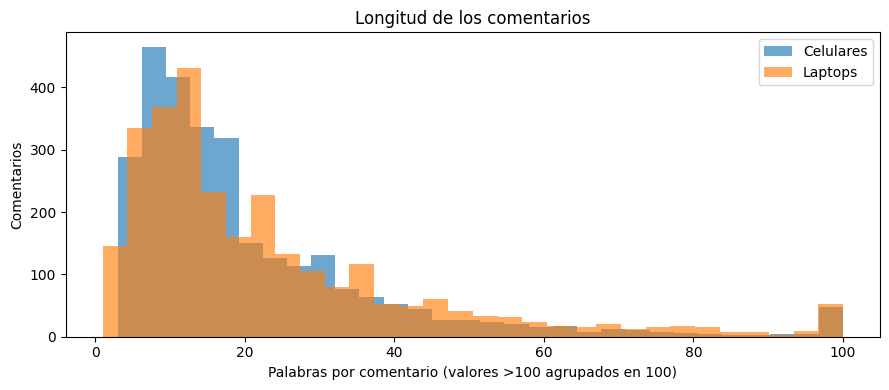

In [4]:
summary = pd.DataFrame({
    "fuente": ["Celulares", "Laptops"],
    "comentarios": [len(phone), len(laptop)],
    "mediana_palabras": [phone["palabras"].median(), laptop["palabras"].median()],
    "p90_palabras": [phone["palabras"].quantile(.9), laptop["palabras"].quantile(.9)],
    "porcentaje_preguntas": [100 * phone["contiene_pregunta"].mean(), 100 * laptop["contiene_pregunta"].mean()],
})
display(summary.round(1))
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(phone["palabras"].clip(upper=100), bins=30, alpha=.65, label="Celulares")
ax.hist(laptop["palabras"].clip(upper=100), bins=30, alpha=.65, label="Laptops")
ax.set(xlabel="Palabras por comentario (valores >100 agrupados en 100)", ylabel="Comentarios", title="Longitud de los comentarios")
ax.legend(); plt.tight_layout(); plt.show()

### Interpretación de la longitud y las preguntas

La mediana es de **15 palabras** en celulares y **16 palabras** en laptops. El 90 % de los textos tiene hasta **42** y **51 palabras**, respectivamente; los máximos son **449** y **506**. El histograma agrupa en 100 los valores superiores a 100 para que el cuerpo de ambas distribuciones sea visible; esos textos largos no desaparecen de los datos.

El **28,4 %** de los comentarios de celulares y el **37,6 %** de los de laptops contiene `?`. Esto sugiere que muchas entradas expresan dudas. El signo es una aproximación: algunas preguntas no llevan `?` y otras frases pueden usarlo sin pedir información.

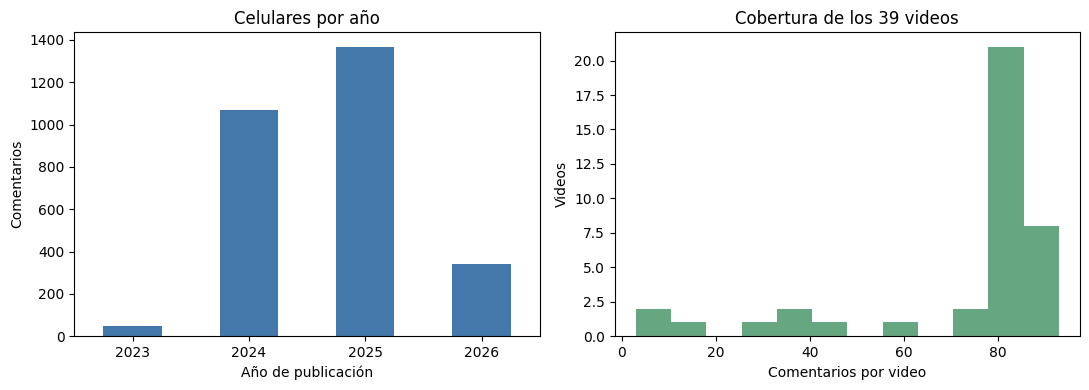

Fechas: 2023-12-09 18:29:07+00:00 a 2026-10-02 16:39:55+00:00
Videos: 39 | canales: 15


In [5]:
phone["anio"] = phone["fecha_publicacion"].dt.year
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
phone["anio"].value_counts().sort_index().plot.bar(ax=axes[0], color="#4477aa")
axes[0].set(xlabel="Año de publicación", ylabel="Comentarios", title="Celulares por año")
axes[0].tick_params(axis="x", rotation=0)
phone["video_id"].value_counts().plot.hist(ax=axes[1], bins=12, color="#66a681")
axes[1].set(xlabel="Comentarios por video", ylabel="Videos", title="Cobertura de los 39 videos")
plt.tight_layout(); plt.show()
print("Fechas:", phone["fecha_publicacion"].min(), "a", phone["fecha_publicacion"].max())
print("Videos:", phone["video_id"].nunique(), "| canales:", phone["channel_id"].nunique())

### Interpretación temporal y por video

El periodo cubierto va del **9 de diciembre de 2023 al 2 de octubre de 2026**. El año con más comentarios es **2025 (1367)**, seguido de **2024 (1067)**, **2026 (341)** y **2023 (50)**. Estos conteos describen la muestra recolectada; no prueban que el interés general por los dispositivos haya cambiado en esa proporción.

Hay **39 videos** de **15 canales**. La mediana es de **83 comentarios por video**, pero el mínimo es **3** y el máximo **93**. La cobertura desigual importa al comparar videos y al evaluar modelos: comentarios del mismo video pueden compartir vocabulario y contexto.

## 4. Interacciones y posible variable de popularidad

Los «me gusta» y las respuestas están disponibles solo para celulares. La distribución se presenta antes de elegir un umbral de popularidad. La fecha y el video pueden afectar la exposición de un comentario; una asociación descriptiva no demuestra causalidad.

,likes,respuestas,palabras
count,2825.00,2825.00,2825.00
mean,1.51,0.51,21.67
std,7.61,1.20,23.58
min,0.00,0.00,3.00
50%,0.00,0.00,15.00
75%,1.00,1.00,26.00
90%,2.00,2.00,42.00
95%,6.00,2.00,58.00
99%,29.00,5.00,115.52
max,193.00,15.00,449.00


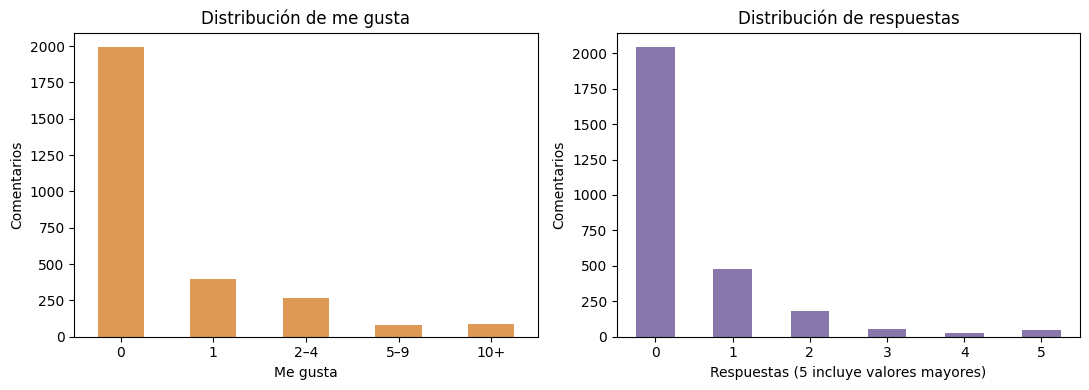

Sin me gusta: 70.5%; con al menos una respuesta: 27.7%


In [6]:
display(phone[["likes", "respuestas", "palabras"]].describe(percentiles=[.5, .75, .9, .95, .99]).round(2))
likes_bins = pd.cut(phone["likes"], bins=[-1, 0, 1, 4, 9, float("inf")], labels=["0", "1", "2–4", "5–9", "10+"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
likes_bins.value_counts().reindex(["0", "1", "2–4", "5–9", "10+"]).plot.bar(ax=axes[0], color="#dd9955")
axes[0].set(xlabel="Me gusta", ylabel="Comentarios", title="Distribución de me gusta")
axes[0].tick_params(axis="x", rotation=0)
phone["respuestas"].clip(upper=5).value_counts().sort_index().plot.bar(ax=axes[1], color="#8877aa")
axes[1].set(xlabel="Respuestas (5 incluye valores mayores)", ylabel="Comentarios", title="Distribución de respuestas")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()
print(f"Sin me gusta: {phone['likes'].eq(0).mean():.1%}; con al menos una respuesta: {phone['respuestas'].gt(0).mean():.1%}")

### Interpretación de las interacciones

La mediana de «me gusta» es **0** y el 90 % de los comentarios tiene **2 o menos**; el máximo es **193**. En total, **70,5 %** tiene cero «me gusta». Solo **27,7 %** recibió al menos una respuesta. Los gráficos muestran una distribución muy asimétrica, por lo que la media por sí sola no resumiría bien el comportamiento.

Si en la siguiente fase se define `popular = likes > 0`, la clase `0` sería mayoritaria. Un clasificador que siempre predijera «sin me gusta» ya obtendría cerca de **70,5 % de exactitud**, pero no reconocería comentarios con interacción. Habrá que justificar la definición de popularidad y revisar métricas por clase. Los «me gusta» tampoco equivalen al sentimiento: una crítica puede recibir apoyo.

## 5. Menciones de marcas

Conteos exploratorios de comentarios que contienen cada palabra. Un comentario puede mencionar varias marcas; por eso las barras no suman el total del corpus. Esta búsqueda simple no clasifica intención ni sentimiento.

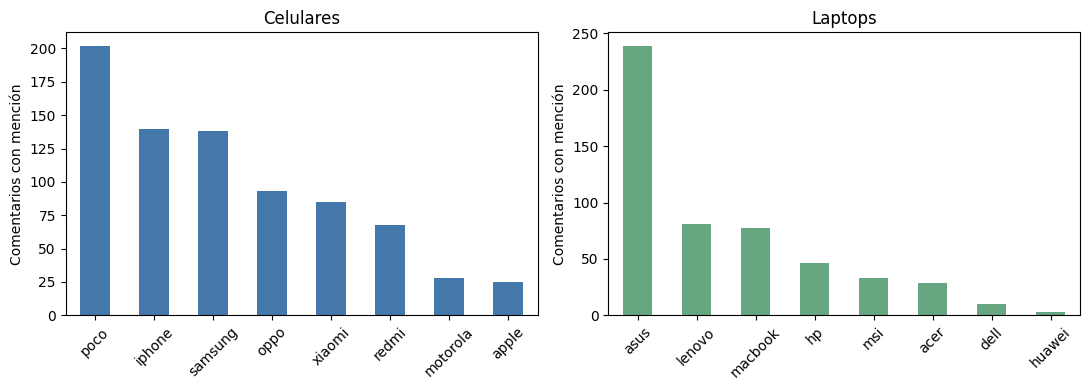

In [7]:
phone_brands = ["samsung", "iphone", "poco", "oppo", "xiaomi", "motorola", "redmi", "apple"]
laptop_brands = ["asus", "macbook", "lenovo", "acer", "hp", "msi", "dell", "huawei"]
def brand_counts(texts, brands):
    return pd.Series({brand: int(texts.str.contains(fr"\b{re.escape(brand)}\b", case=False, regex=True).sum()) for brand in brands}).sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
brand_counts(phone["texto"], phone_brands).plot.bar(ax=axes[0], color="#4477aa")
brand_counts(laptop["texto"], laptop_brands).plot.bar(ax=axes[1], color="#66a681")
axes[0].set(title="Celulares", ylabel="Comentarios con mención")
axes[1].set(title="Laptops", ylabel="Comentarios con mención")
for ax in axes: ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

### Interpretación de las menciones

En celulares, los términos detectados con más frecuencia son **«poco» (202)**, **«iphone» (140)** y **«samsung» (138)**. En laptops destacan **«asus» (239)**, **«lenovo» (81)** y **«macbook» (77)**. Un comentario puede contar en varias barras cuando compara marcas.

Este conteo es exploratorio. En español, **«poco»** también es una palabra común, así que sus 202 coincidencias no deben interpretarse como 202 menciones confirmadas de la marca POCO. Tampoco se puede inferir preferencia o sentimiento a partir de mencionar una marca.

## 6. Inspección de miniaturas

,ancho,alto,formato,cantidad
0,1280,720,JPEG,29


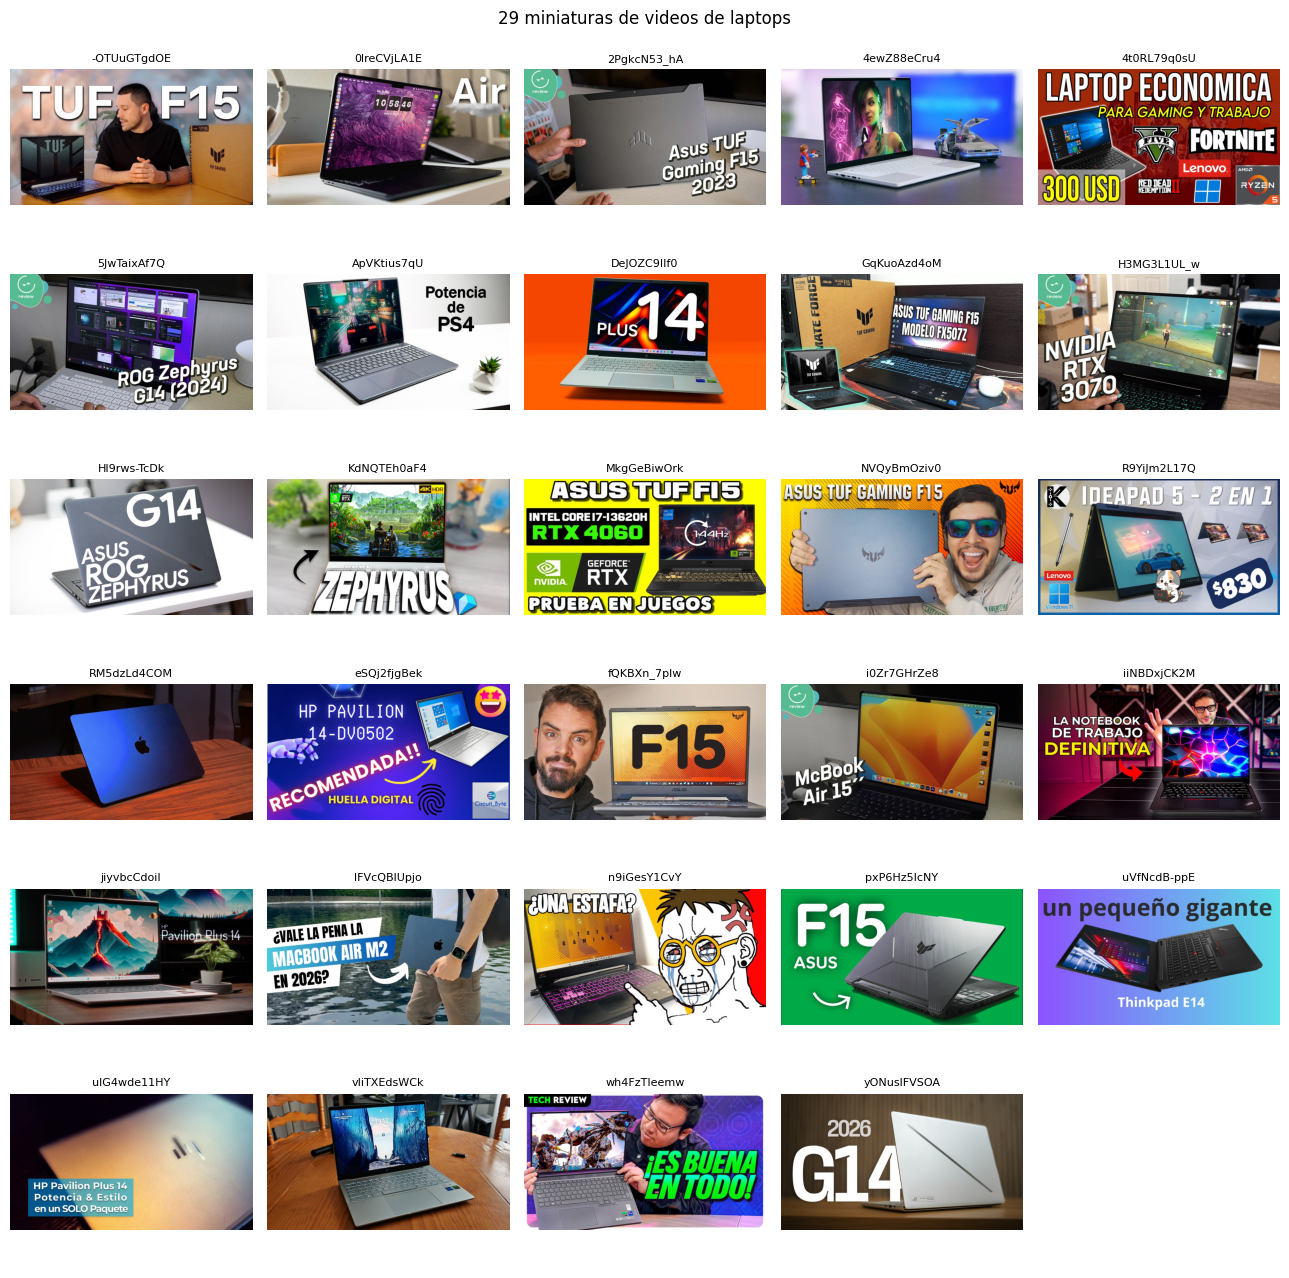

In [8]:
image_info = []
for path in image_paths:
    with Image.open(path) as im:
        image_info.append({"archivo": path.name, "ancho": im.width, "alto": im.height, "formato": im.format})
images = pd.DataFrame(image_info)
display(images.groupby(["ancho", "alto", "formato"]).size().rename("cantidad").reset_index())
assert len(images) == 29 and images[["ancho", "alto"]].eq([1280, 720]).all().all()
fig, axes = plt.subplots(6, 5, figsize=(13, 13))
for ax, path in zip(axes.flat, image_paths):
    with Image.open(path) as im: ax.imshow(im)
    ax.set_title(path.stem[-11:], fontsize=8)
    ax.axis("off")
for ax in list(axes.flat)[len(image_paths):]: ax.axis("off")
fig.suptitle("29 miniaturas de videos de laptops")
plt.tight_layout(); plt.show()

### Interpretación de las imágenes

Las **29 miniaturas** se pudieron abrir y todas tienen resolución **1280 × 720**. La cuadrícula permite comprobar visualmente que corresponden a videos sobre laptops de distintas marcas y modelos. La imagen identifica el video por su nombre de archivo, pero el TXT no conserva un `video_id` por comentario; por ello no se asigna una miniatura específica a ninguna línea del TXT.

## 7. Datos preparados para la siguiente fase

Se exportan campos útiles y texto con espacios normalizados. No se infiere sentimiento ni se fabrican metadatos ausentes. `likes` y `respuestas` se conservan para estudiar la popularidad, aunque la definición de la variable objetivo debe decidirse antes del modelado.

In [9]:
phone_out = DATA / "dataset_preparado_celulares.csv"
laptop_out = DATA / "dataset_preparado_laptops.csv"
phone.drop(columns="anio").to_csv(phone_out, index=False, encoding="utf-8")
laptop.to_csv(laptop_out, index=False, encoding="utf-8")
assert len(pd.read_csv(phone_out)) == len(phone)
assert len(pd.read_csv(laptop_out)) == len(laptop)
print("Exportados:", phone_out, "y", laptop_out)

Exportados: ../data/dataset_preparado_celulares.csv y ../data/dataset_preparado_laptops.csv


### Interpretación de la exportación

Los CSV preparados contienen **2825 filas de celulares** y **2819 de laptops**, con el texto normalizado y variables descriptivas. El archivo de celulares conserva fecha, video, «me gusta» y respuestas; el de laptops conserva el número de línea original para rastrear cada entrada. La comprobación de filas tras releer los CSV confirma que la exportación no perdió registros utilizables. **No se añadieron etiquetas de sentimiento ni valores de popularidad inventados.**

## 8. Hallazgos y decisiones para modelización

1. **Tamaño y cobertura.** Hay 2825 comentarios de celulares de 39 videos y 15 canales. El TXT tiene 2852 líneas, 33 vacías y 2819 comentarios utilizables; el número 2853 del avance debe revisarse.
2. **Calidad.** El JSON no tiene nulos en sus 24 campos ni IDs repetidos; existen 17 textos exactamente repetidos. En el TXT hay 9 textos exactamente repetidos entre las líneas no vacías.
3. **Texto.** La mediana es 15 palabras en celulares y 16 en laptops. Hay comentarios muy largos, por lo que conviene revisar extremos antes de modelar.
4. **Popularidad.** El 70,5 % de los comentarios de celulares tiene 0 me gusta. Si se define una clase «popular», se debe justificar el umbral y medir el desbalance. Para una predicción realista, usar solo variables disponibles al publicarse el comentario; `respuestas` puede llegar después y producir fuga de información.
5. **Sentimiento.** Ninguna fuente incluye etiquetas positivo/neutro/negativo. Para evaluar un clasificador se necesita un conjunto etiquetado y revisado; la polaridad no debe deducirse de los me gusta.
6. **Integración.** El TXT no incluye ID de video, fecha ni me gusta por comentario. Por eso las laptops y sus miniaturas no pueden entrar directamente al mismo experimento supervisado de popularidad que los celulares.

**Alcance del EDA:** estas cifras describen los archivos actuales. La clasificación y las métricas de rendimiento corresponden a la siguiente etapa del proyecto.